
# V3 최종 모델 Feature Importance / SHAP 분석 — Standalone

이 노트북은 **기존 V3 성능 탐색 노트북의 런타임 변수에 의존하지 않습니다.**

직접 다음 파일/모듈을 다시 읽습니다.

- `results_v3/run_full/champion_selection_only.joblib`
- `results_v3/run_full/selected_recipe.json`
- `results_v3/run_full/selection_predictions.csv`
- `results_v3/run_full/candidates/*.json`
- `lifelog_v3/`
- `lifelog_v2/`
- 원본 Training / Validation activity·sleep·label CSV

분석 대상은 현재 V3와 동일하게 고정합니다.

- 전체 174명
- Training 141명: CN 85 / MCI 47 / DEM 9
- Selection Validation 33명: CN 26 / MCI 4 / DEM 3
- 피험자 단위 완전 분리
- MMSE 미사용

## 이 노트북이 만드는 결과

1. 저장된 V3 champion을 다시 로드하고 기존 예측값과 **정확히 재현되는지 검증**
2. 최종 3-class ensemble 전체에 대한 **Permutation Importance**
   - 기본 지표: Macro ROC-AUC 감소량
   - 클래스별 CN/MCI/DEM OVR AUC 감소량도 함께 저장
3. 최종 의사결정값  
   `log(class_score) + class_offset`  
   에 대한 **class-specific SHAP**
4. 계층형 분기별 SHAP
   - DEM vs non-DEM
   - CN vs MCI
5. CSV와 PNG를 `results_v3/run_full/shap_analysis/`에 저장

> 중요: 현재 Validation은 V3 모델·가중치·offset 선택에도 사용되었습니다.  
> 따라서 여기서 얻는 SHAP/importance는 **현재 선택된 champion이 무엇을 사용했는지 설명하는 모델 해석**이며, 독립 외부 검증 결과로 해석하지 않습니다.


In [1]:

from pathlib import Path
import json
import sys
import warnings
import importlib.metadata as im

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, Markdown

# -----------------------------
# 사용자 설정
# -----------------------------
PROJECT_ROOT = Path.cwd()
RUN_DIR = PROJECT_ROOT / "results_v3" / "run_full"
OUT_DIR = RUN_DIR / "shap_analysis"

# 기존 V3 노트북과 동일:
# None이면 lifelog_v2.feature_engineering.resolve_paths()가 프로젝트 내부 Data 경로를 자동 탐색합니다.
DATA_ROOT = None

SEED = 2026
THREADS = 4

# 첫 실행 권장: 30~50
# 최종 논문용 안정성 확인 시 100~200으로 늘릴 수 있습니다.
N_PERM_REPEATS = 50

# SHAP background 최대 피험자 수
SHAP_BACKGROUND_MAX = 80

# 전체 Validation 33명을 기본적으로 모두 설명합니다.
# 빠른 테스트가 필요하면 예: 10
FINAL_SHAP_MAX_ROWS = None
BRANCH_SHAP_MAX_ROWS = None

# joblib 로드가 환경 버전 차이로 실패하면 선택된 4개 모델만 다시 fit합니다.
ALLOW_REBUILD_IF_JOBLIB_FAILS = True

RUN_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [
    RUN_DIR / "selected_recipe.json",
    RUN_DIR / "selection_predictions.csv",
    RUN_DIR / "manifest.json",
    RUN_DIR / "candidates",
]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError(
        "다음 V3 결과 파일/폴더가 없습니다.\n" + "\n".join(missing)
    )

if not (PROJECT_ROOT / "lifelog_v3").is_dir():
    raise RuntimeError(
        "이 노트북을 my_lab 프로젝트 루트에서 실행하세요. "
        "현재 작업 폴더에 lifelog_v3/가 없습니다."
    )
if not (PROJECT_ROOT / "lifelog_v2").is_dir():
    raise RuntimeError(
        "현재 작업 폴더에 lifelog_v2/가 없습니다."
    )

print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("RUN_DIR     :", RUN_DIR.resolve())
print("OUT_DIR     :", OUT_DIR.resolve())


PROJECT_ROOT: /Users/pig30nidae/my_lab
RUN_DIR     : /Users/pig30nidae/my_lab/results_v3/run_full
OUT_DIR     : /Users/pig30nidae/my_lab/results_v3/run_full/shap_analysis



## 1. 실행 환경 확인

`champion_selection_only.joblib`은 모델 객체 전체를 저장한 파일이므로, **원래 V3 실행 환경과 pandas / scikit-learn 등의 버전이 크게 다르면 joblib 로드가 실패할 수 있습니다.**

이 노트북은 먼저 저장 모델을 로드합니다. 실패하면 `selected_recipe.json`과 각 candidate JSON을 이용해 **최종 선택된 4개 모델만 Training 141명으로 다시 fit**하는 fallback을 제공합니다.

자동으로 패키지를 업그레이드하지 않습니다. 기존 모델 파일의 호환성을 깨뜨릴 수 있기 때문입니다.


In [2]:

manifest = json.loads((RUN_DIR / "manifest.json").read_text())
recorded_versions = manifest.get("versions", {})

package_map = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "scikit-learn": "scikit-learn",
    "catboost": "catboost",
    "joblib": "joblib",
}

rows = []
for label, pkg in package_map.items():
    try:
        current = im.version(pkg)
    except im.PackageNotFoundError:
        current = "NOT INSTALLED"
    rows.append({
        "package": label,
        "V3 recorded": recorded_versions.get(label, "n/a"),
        "current": current,
        "same": current == recorded_versions.get(label)
    })

env_table = pd.DataFrame(rows)
display(env_table)

try:
    import shap
except ImportError as e:
    raise ImportError(
        "SHAP가 설치되어 있지 않습니다. 기존 V3 핵심 패키지는 업그레이드하지 말고 "
        "현재 환경에 shap만 설치한 뒤 커널을 재시작하세요."
    ) from e

print("SHAP version:", shap.__version__)

from scipy.special import expit, logit
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, confusion_matrix

from lifelog_v3.data import prepare
from lifelog_v3.models import Spec, fit_candidate, model_scores
from lifelog_v3.selection import Champion, recipe_scores, recipe_ids


,package,V3 recorded,current,same
0,numpy,2.5.3,2.5.3,True
1,pandas,3.0.6,3.0.6,True
2,scipy,1.18.1,1.18.1,True
3,scikit-learn,1.9.1,1.9.1,True
4,catboost,1.2.10,1.2.10,True
5,joblib,1.6.0,1.6.0,True


SHAP version: 0.52.0


/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## 2. Training / Validation feature matrix 다시 준비

기존 노트북의 `training`, `selection` 변수를 사용하지 않고 `prepare()`를 다시 호출합니다.

이미 `results_v2/cache/`, `results_v3/cache/`가 남아 있다면 빠르게 로드됩니다.  
캐시가 없다면 원본 CSV로 feature를 다시 추출하므로 시간이 걸릴 수 있지만, **새 모델 탐색을 다시 수행하는 것은 아닙니다.**


In [3]:

training, selection = prepare(DATA_ROOT)

assert set(training.subjects).isdisjoint(selection.subjects)
assert training.representations["subject"].X.columns.equals(
    selection.representations["subject"].X.columns
)

CLASS_NAMES = np.array(["CN", "MCI", "DEM"])

train_counts = training.labels.value_counts().sort_index()
val_counts = selection.labels.value_counts().sort_index()

expected_train = {0: 85, 1: 47, 2: 9}
expected_val = {0: 26, 1: 4, 2: 3}

assert len(training.subjects) == 141, len(training.subjects)
assert len(selection.subjects) == 33, len(selection.subjects)
assert train_counts.to_dict() == expected_train, train_counts.to_dict()
assert val_counts.to_dict() == expected_val, val_counts.to_dict()

display(pd.DataFrame({
    "Training": pd.Series(expected_train).rename(index={0:"CN",1:"MCI",2:"DEM"}),
    "Selection Validation": pd.Series(expected_val).rename(index={0:"CN",1:"MCI",2:"DEM"}),
}))

print("Training–Validation subject overlap:",
      len(set(training.subjects) & set(selection.subjects)))
print("전체 피험자:", len(training.subjects) + len(selection.subjects))


Using feature cache: features_ace307489ac40f60e694f469333865e85f633185d25a307c89d656cb2be27f30.joblib
Using feature cache: features_2148c23335900b8a8a9da91a05df46d161e3fec7f577d20e061366499d3eac66.joblib
{
  "classifier_training_executed": false,
  "subject_overlap": 0,
  "splits": {
    "Training": {
      "subjects": 141,
      "class_counts": {
        "CN": 85,
        "MCI": 47,
        "DEM": 9
      },
      "representations": {
        "subject_v1": {
          "rows": 141,
          "features": 670
        },
        "subject_plus": {
          "rows": 141,
          "features": 1333
        },
        "window14": {
          "rows": 784,
          "features": 1333
        },
        "window28": {
          "rows": 449,
          "features": 1333
        },
        "subject": {
          "rows": 141,
          "features": 5144
        }
      }
    },
    "SelectionValidation": {
      "subjects": 33,
      "class_counts": {
        "CN": 26,
        "MCI": 4,
        "DEM": 3

,Training,Selection Validation
CN,85,26
MCI,47,4
DEM,9,3


Training–Validation subject overlap: 0
전체 피험자: 174



## 3. 최종 champion 로드 — 실패 시 정확한 4개 모델만 재구성

우선 `champion_selection_only.joblib`을 사용합니다.

joblib이 버전 문제로 로드되지 않는 경우에만:

- `selected_recipe.json`에서 최종 recipe 확인
- recipe가 실제 사용하는 candidate ID 4개 확인
- 각 candidate JSON의 **동일 spec**
- Training 141명만 사용

으로 다시 fit합니다.

재구성 후에는 반드시 기존 `selection_predictions.csv`와 score를 대조합니다.  
**기존 champion과 예측이 재현되지 않으면 SHAP 단계로 진행하지 않습니다.**


In [4]:

recipe_doc = json.loads((RUN_DIR / "selected_recipe.json").read_text())
recipe = recipe_doc["recipe"]
offsets = np.asarray(recipe_doc["offsets"], dtype=float)

MODEL_PATH = RUN_DIR / "champion_selection_only.joblib"

def rebuild_champion_from_saved_specs():
    ids = sorted(recipe_ids(recipe))
    models = {}

    print("재구성할 최종 candidate:", ids)
    for cid in ids:
        candidate_path = RUN_DIR / "candidates" / f"{cid}.json"
        if not candidate_path.exists():
            raise FileNotFoundError(candidate_path)

        record = json.loads(candidate_path.read_text())
        spec = Spec(**record["spec"])

        print(
            f"  fitting {cid}: "
            f"task={spec.task}, family={spec.family}, "
            f"view={spec.view}, top_k={spec.top_k}"
        )

        fitted = fit_candidate(training, spec, threads=THREADS)

        saved_features = list(record["selected_features"])
        rebuilt_features = list(fitted.processor.columns)

        if rebuilt_features != saved_features:
            raise RuntimeError(
                f"{cid}의 selected feature가 원 실험과 달라졌습니다.\n"
                "현재 라이브러리 버전이 V3 manifest와 다른지 확인하세요."
            )

        models[cid] = fitted

    return Champion(
        models=models,
        recipe=recipe,
        offsets=offsets,
        protocol={"rebuilt_for_shap": True}
    )

champion_source = None

if MODEL_PATH.exists():
    try:
        champion = joblib.load(MODEL_PATH)
        champion_source = "saved joblib"
        print("Champion 로드 성공:", MODEL_PATH)
    except Exception as e:
        print("Champion joblib 로드 실패:")
        print(type(e).__name__, str(e))
        if not ALLOW_REBUILD_IF_JOBLIB_FAILS:
            raise
        print("\n저장된 candidate spec으로 최종 4개 모델만 재구성합니다.")
        champion = rebuild_champion_from_saved_specs()
        champion_source = "rebuilt from saved candidate specs"
else:
    if not ALLOW_REBUILD_IF_JOBLIB_FAILS:
        raise FileNotFoundError(MODEL_PATH)
    champion = rebuild_champion_from_saved_specs()
    champion_source = "rebuilt from saved candidate specs"

print("Champion source:", champion_source)
print("Offsets:", np.asarray(champion.offsets))
print("Recipe kind:", champion.recipe["kind"])
print("Model IDs:", sorted(champion.models))


Champion 로드 성공: /Users/pig30nidae/my_lab/results_v3/run_full/champion_selection_only.joblib
Champion source: saved joblib
Offsets: [ 0.         -0.76527604 -0.33713972]
Recipe kind: ensemble
Model IDs: ['656311e259644cea8370a3fd', '83966b1bcba5784bf3b711dc', 'be0a10df641d92bfee639d33', 'd02843f9ccbf76116ea9a456']



## 4. 기존 V3 예측과 정확히 일치하는지 검증

여기서 실패하면 뒤의 SHAP 결과는 원래 V3 champion 설명이 아니므로 중단합니다.


In [5]:

saved_pred = pd.read_csv(RUN_DIR / "selection_predictions.csv").set_index("subject_hash")
saved_pred = saved_pred.reindex(selection.subjects)

p_check, h_check = champion.predict(selection.representations, selection.subjects)
pred_check = CLASS_NAMES[h_check]

saved_scores = saved_pred[["score_CN", "score_MCI", "score_DEM"]].to_numpy(float)
max_abs_score_diff = float(np.max(np.abs(p_check - saved_scores)))
pred_match_rate = float(np.mean(pred_check == saved_pred["predicted"].to_numpy()))

print("max |reproduced score - saved score| =", max_abs_score_diff)
print("predicted label match rate           =", pred_match_rate)

# 저장 반올림 오차를 고려하되, 다른 모델을 설명하는 상황은 차단합니다.
if max_abs_score_diff > 1e-6 or pred_match_rate < 1.0:
    raise RuntimeError(
        "현재 재현된 champion이 저장된 V3 예측과 정확히 일치하지 않습니다. "
        "SHAP을 진행하지 마세요. manifest의 패키지 버전과 실행 환경을 먼저 맞춰야 합니다."
    )

y_val = selection.labels.reindex(selection.subjects).to_numpy(int)

macro_auc = roc_auc_score(
    y_val, p_check, multi_class="ovr", average="macro"
)
accuracy = accuracy_score(y_val, h_check)
macro_recall = recall_score(y_val, h_check, average="macro")

print(f"Macro ROC-AUC : {macro_auc:.12f}")
print(f"Accuracy      : {accuracy:.12f}")
print(f"Macro recall  : {macro_recall:.12f}")
print("Confusion matrix:")
display(pd.DataFrame(
    confusion_matrix(y_val, h_check, labels=[0,1,2]),
    index=["true_CN","true_MCI","true_DEM"],
    columns=["pred_CN","pred_MCI","pred_DEM"],
))


max |reproduced score - saved score| = 8.326672684688674e-17
predicted label match rate           = 1.0
Macro ROC-AUC : 0.975937855248
Accuracy      : 0.969696969697
Macro recall  : 0.987179487179
Confusion matrix:


,pred_CN,pred_MCI,pred_DEM
true_CN,25,1,0
true_MCI,0,4,0
true_DEM,0,0,3



## 5. 최종 champion 구성과 실제 사용 feature 확인

최종 모델은 단일 classifier가 아니라:

- hierarchy 1: DEM branch + CN/MCI branch
- hierarchy 2: DEM branch + CN/MCI branch
- class-wise soft voting
- global class offsets

구조입니다.

여기서 각 component의 selected feature와 최종 union을 추출합니다.


In [6]:

STATE_LABELS = {
    0: "non_wear",
    1: "rest",
    2: "inactive",
    3: "low_intensity_activity",
    4: "medium_intensity_activity",
    5: "high_intensity_activity",
}

def readable_feature_name(name):
    out = str(name)
    for code, label in STATE_LABELS.items():
        out = out.replace(f"state_code_{code}", f"state_{code}_{label}")
    return out

component_rows = []
ordered_component_ids = []

for h_idx, member in enumerate(champion.recipe["members"], start=1):
    for role, key in [("DEM_vs_nonDEM", "dem_id"), ("MCI_vs_CN", "cn_mci_id")]:
        cid = member[key]
        ordered_component_ids.append(cid)
        fitted = champion.models[cid]

        if role == "DEM_vs_nonDEM":
            temp = member.get("dem_temperature", 1.0)
            bias = member.get("dem_bias", 0.0)
        else:
            temp = member.get("cn_mci_temperature", 1.0)
            bias = member.get("cn_mci_bias", 0.0)

        component_rows.append({
            "hierarchy": h_idx,
            "role": role,
            "candidate_id": cid,
            "family": fitted.spec.family,
            "view": fitted.spec.view,
            "n_features": len(fitted.processor.columns),
            "transform": fitted.spec.transform,
            "pca": fitted.spec.pca,
            "augmentation": fitted.spec.augmentation,
            "temperature": temp,
            "bias": bias,
        })

component_table = pd.DataFrame(component_rows)
display(component_table)
component_table.to_csv(OUT_DIR / "component_inventory.csv", index=False)

# recipe 순서를 보존한 unique component ID
ordered_component_ids = list(dict.fromkeys(ordered_component_ids))

union_features = []
for cid in ordered_component_ids:
    union_features.extend(champion.models[cid].processor.columns)
union_features = list(dict.fromkeys(union_features))

print("최종 component 수:", len(ordered_component_ids))
print("최종 unique raw engineered features:", len(union_features))

context_features = [f for f in union_features if f.startswith("context__")]
print("collection-context feature 수:", len(context_features))
if context_features:
    display(context_features)

feature_meta = training.representations["subject"].meta.reindex(union_features).copy()
feature_meta.index.name = "feature"
feature_meta["feature_readable"] = [readable_feature_name(x) for x in feature_meta.index]
feature_meta.to_csv(OUT_DIR / "champion_feature_dictionary.csv")

display(feature_meta.head(20))


,hierarchy,role,candidate_id,family,view,n_features,transform,pca,augmentation,temperature,bias
0,1,DEM_vs_nonDEM,be0a10df641d92bfee639d33,rbf_ridge,activity,20,quantile,0,smote,0.383138,-0.757257
1,1,MCI_vs_CN,83966b1bcba5784bf3b711dc,lda,compact,15,signedlog,0,smote,1.649773,0.608185
2,2,DEM_vs_nonDEM,d02843f9ccbf76116ea9a456,rbf_ridge,activity,80,standard,15,none,2.530861,0.626597
3,2,MCI_vs_CN,656311e259644cea8370a3fd,logreg,compact,15,standard,30,none,1.853388,1.249311


최종 component 수: 4
최종 unique raw engineered features: 95
collection-context feature 수: 0


,modality,family,description,kind,feature_readable
feature,,,,,
v3__activity__met_p10__maximum,activity,physiology,activity__met_p10: within-person maximum; cale...,temporal_v3,v3__activity__met_p10__maximum
activity__met_p10__p90,activity,physiology,CONVERT(activity_met_1min USING utf8): p10; ac...,v2,activity__met_p10__p90
v3__activity__met_p10__q95,activity,physiology,activity__met_p10: within-person q95; calendar...,temporal_v3,v3__activity__met_p10__q95
v3__activity__state_transition_rate__rolling_range7,activity,physiology,activity__state_transition_rate: within-person...,temporal_v3,v3__activity__state_transition_rate__rolling_r...
v3__activity__low__rolling_range14,activity,physiology,activity__low: within-person rolling_range14; ...,temporal_v3,v3__activity__low__rolling_range14
v3__activity__low__rolling_range28,activity,physiology,activity__low: within-person rolling_range28; ...,temporal_v3,v3__activity__low__rolling_range28
v3__activity__state_transition_rate__rolling_range14,activity,physiology,activity__state_transition_rate: within-person...,temporal_v3,v3__activity__state_transition_rate__rolling_r...
v3__activity__met_day_night_difference__kurtosis,activity,physiology,activity__met_day_night_difference: within-per...,temporal_v3,v3__activity__met_day_night_difference__kurtosis
v3__activity__met_cosinor_phase_cos__bin_variance4,activity,physiology,activity__met_cosinor_phase_cos: within-person...,temporal_v3,v3__activity__met_cosinor_phase_cos__bin_varia...



## 6. SHAP/Permutation용 "원시 feature → 최종 champion score" wrapper

`Fitted.predict()`를 우회해서 다른 모델을 만드는 것이 아니라, 저장된 각 component의

- 동일 selected columns
- 동일 median
- 동일 transform
- 동일 scaler
- 동일 PCA
- 동일 estimator

를 그대로 호출합니다.

그 뒤 원래 `recipe_scores()`와 offsets까지 그대로 적용합니다.

이 wrapper가 기존 champion의 `predict()`와 동일한지 다시 검증합니다.


In [7]:

X_train_all = training.representations["subject"].X.reindex(training.subjects)
X_val_all = selection.representations["subject"].X.reindex(selection.subjects)

X_train_union = X_train_all[union_features].copy()
X_val_union = X_val_all[union_features].copy()

def component_scores_from_frame(candidate_id, X_frame):
    fitted = champion.models[candidate_id]
    Xt = fitted.processor.transform(X_frame)
    return model_scores(
        fitted.model,
        Xt,
        fitted.spec.family,
        fitted.n_classes
    )

def final_class_scores_from_frame(X_frame):
    predictions = {
        cid: component_scores_from_frame(cid, X_frame)
        for cid in ordered_component_ids
    }
    return recipe_scores(champion.recipe, predictions)

def final_decision_scores_from_frame(X_frame):
    p = final_class_scores_from_frame(X_frame)
    return np.log(np.clip(p, 1e-12, 1.0)) + np.asarray(champion.offsets)

p_wrapper = final_class_scores_from_frame(X_val_union)
d_wrapper = final_decision_scores_from_frame(X_val_union)
h_wrapper = d_wrapper.argmax(axis=1)

print("Wrapper score max diff:",
      np.max(np.abs(p_wrapper - p_check)))
print("Wrapper decision match:",
      np.mean(h_wrapper == h_check))

assert np.allclose(p_wrapper, p_check, atol=1e-10, rtol=1e-10)
assert np.array_equal(h_wrapper, h_check)


Wrapper score max diff: 0.0
Wrapper decision match: 1.0



# A. 최종 3-class ensemble Permutation Importance

이 분석은 **최종 ensemble 전체**를 대상으로 합니다.

각 feature를 Validation 33명 사이에서 무작위로 섞고 최종 class score를 다시 계산한 뒤,

- Macro ROC-AUC 감소
- CN OVR AUC 감소
- MCI OVR AUC 감소
- DEM OVR AUC 감소

를 측정합니다.

**Primary importance는 `delta_macro_auc_mean`** 으로 사용합니다.

Validation이 33명으로 작기 때문에 한 번의 permutation 대신 여러 번 반복하여 평균과 표준편차를 저장합니다.


 10/95 features 완료
 20/95 features 완료
 30/95 features 완료
 40/95 features 완료
 50/95 features 완료
 60/95 features 완료
 70/95 features 완료
 80/95 features 완료
 90/95 features 완료
 95/95 features 완료
Baseline AUC: {np.str_('CN'): 0.945054945054945, np.str_('MCI'): 0.9827586206896552, np.str_('DEM'): 1.0, 'macro': 0.9759378552482}


,feature,feature_readable,delta_macro_auc_mean,delta_macro_auc_sd,delta_macro_auc_median,delta_macro_auc_q05,delta_macro_auc_q95,delta_auc_CN_mean,delta_auc_CN_sd,delta_auc_MCI_mean,delta_auc_MCI_sd,delta_auc_DEM_mean,delta_auc_DEM_sd,modality,family,description,kind
0,v3__activity__state_code_3_longest_minutes__ma...,v3__activity__state_3_low_intensity_activity_l...,0.099068,0.037801,0.098225,0.044848,0.158311,0.166593,0.070385,0.033276,0.078972,0.097333,0.036096,activity,physiology,activity__state_code_3_longest_minutes: within...,temporal_v3
1,v3__activity__state_transition_rate__stv7,v3__activity__state_transition_rate__stv7,0.092569,0.039040,0.097223,0.022639,0.153515,0.067143,0.027535,0.161897,0.111958,0.048667,0.030523,activity,physiology,activity__state_transition_rate: within-person...,temporal_v3
2,v3__activity__state_transition_rate__rolling_r...,v3__activity__state_transition_rate__rolling_r...,0.080811,0.044367,0.069586,0.024199,0.163328,0.102637,0.056378,0.072241,0.092846,0.067556,0.037952,activity,physiology,activity__state_transition_rate: within-person...,temporal_v3
3,v3__activity__state_code_3_longest_minutes__range,v3__activity__state_3_low_intensity_activity_l...,0.064128,0.023666,0.071774,0.001667,0.082915,-0.003297,0.006181,0.178793,0.067224,0.016889,0.008763,activity,physiology,activity__state_code_3_longest_minutes: within...,temporal_v3
4,v3__sleep__paper_hr_drop_ratio__std,v3__sleep__paper_hr_drop_ratio__std,0.059053,0.025691,0.057755,0.026719,0.102940,0.058022,0.029331,0.119138,0.050738,0.000000,0.000000,sleep,physiology,sleep__paper_hr_drop_ratio: within-person std;...,temporal_v3
5,sleep__bedtime_regularity,sleep__bedtime_regularity,0.056228,0.033001,0.049782,0.014289,0.112375,0.049890,0.033722,0.118793,0.067415,0.000000,0.000000,sleep,physiology,시각 원형 resultant length: 1에 가까울수록 규칙적,v2
6,v3__activity__low__std,v3__activity__low__std,0.054871,0.023378,0.056192,0.015053,0.084909,0.053407,0.025045,0.111207,0.047990,0.000000,0.000000,activity,physiology,activity__low: within-person std; calendar win...,temporal_v3
7,v3__activity__state_code_3_longest_minutes__ro...,v3__activity__state_3_low_intensity_activity_l...,0.046573,0.025846,0.056470,0.000355,0.074541,-0.006044,0.004335,0.136207,0.073727,0.009556,0.007448,activity,physiology,activity__state_code_3_longest_minutes: within...,temporal_v3
8,v3__activity__steps__std,v3__activity__steps__std,0.045813,0.034702,0.042923,-0.002736,0.105992,0.056264,0.044962,0.073621,0.059909,0.007556,0.005236,activity,physiology,activity__steps: within-person std; calendar w...,temporal_v3
9,v3__activity__rest__range,v3__activity__rest__range,0.044295,0.027466,0.050511,-0.001832,0.074284,-0.004505,0.008209,0.126724,0.081341,0.010667,0.008387,activity,physiology,activity__rest: within-person range; calendar ...,temporal_v3


saved: /Users/pig30nidae/my_lab/results_v3/run_full/shap_analysis/final_ensemble_permutation_importance.csv


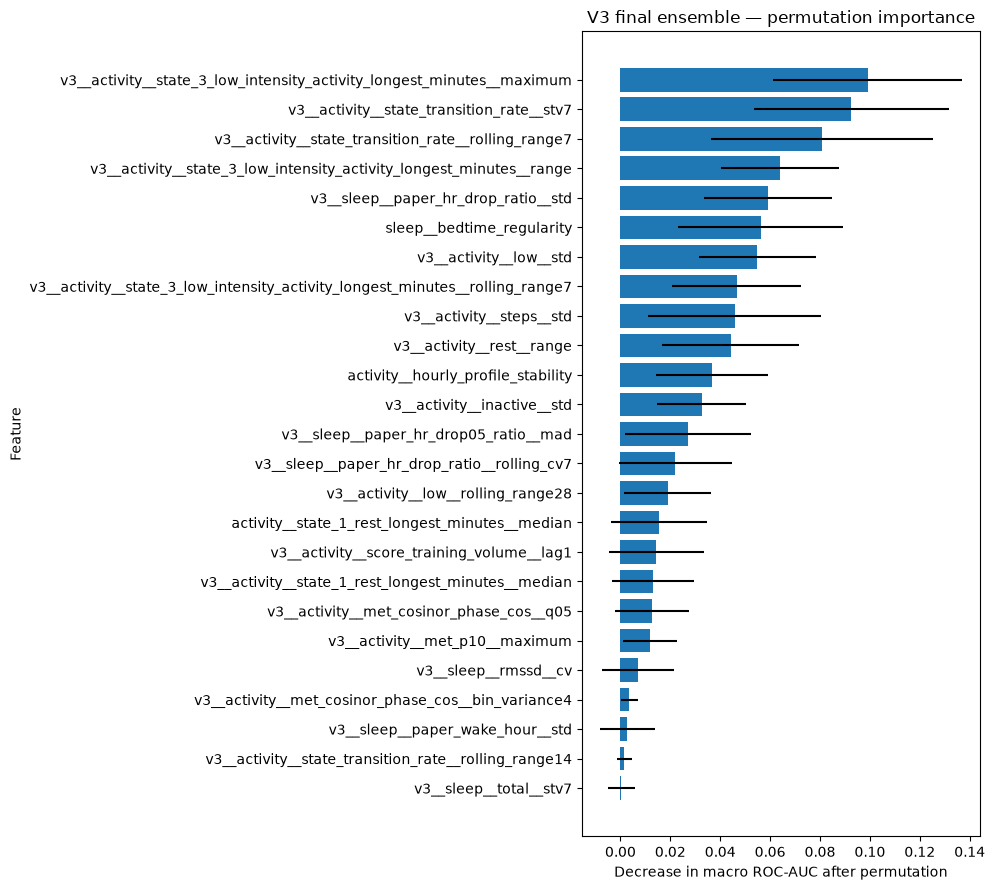

In [8]:

def class_auc_vector(y, p):
    result = {}
    for k, name in enumerate(CLASS_NAMES):
        result[name] = roc_auc_score((y == k).astype(int), p[:, k])
    result["macro"] = float(np.mean(list(result.values())))
    return result

def final_permutation_importance(
    X,
    y,
    features,
    n_repeats=50,
    seed=2026,
):
    rng = np.random.default_rng(seed)

    base_p = final_class_scores_from_frame(X)
    base_auc = class_auc_vector(y, base_p)

    rows = []
    n = len(X)

    for i, feature in enumerate(features, start=1):
        delta_macro = []
        delta_by_class = {name: [] for name in CLASS_NAMES}

        original = X[feature].to_numpy(copy=True)

        for _ in range(n_repeats):
            perm = rng.permutation(n)
            Xp = X.copy()
            Xp[feature] = original[perm]

            pp = final_class_scores_from_frame(Xp)
            aucs = class_auc_vector(y, pp)

            delta_macro.append(base_auc["macro"] - aucs["macro"])
            for name in CLASS_NAMES:
                delta_by_class[name].append(base_auc[name] - aucs[name])

        row = {
            "feature": feature,
            "feature_readable": readable_feature_name(feature),
            "delta_macro_auc_mean": float(np.mean(delta_macro)),
            "delta_macro_auc_sd": float(np.std(delta_macro, ddof=1)),
            "delta_macro_auc_median": float(np.median(delta_macro)),
            "delta_macro_auc_q05": float(np.quantile(delta_macro, 0.05)),
            "delta_macro_auc_q95": float(np.quantile(delta_macro, 0.95)),
        }
        for name in CLASS_NAMES:
            vals = np.asarray(delta_by_class[name], float)
            row[f"delta_auc_{name}_mean"] = float(vals.mean())
            row[f"delta_auc_{name}_sd"] = float(vals.std(ddof=1))

        rows.append(row)

        if i % 10 == 0 or i == len(features):
            print(f"{i:>3}/{len(features)} features 완료")

    out = pd.DataFrame(rows)

    meta = training.representations["subject"].meta.copy()
    meta.index.name = "feature"
    meta = meta.reset_index()

    out = out.merge(meta, on="feature", how="left")
    out = out.sort_values("delta_macro_auc_mean", ascending=False).reset_index(drop=True)
    return out, base_auc

perm_importance, baseline_auc = final_permutation_importance(
    X_val_union,
    y_val,
    union_features,
    n_repeats=N_PERM_REPEATS,
    seed=SEED,
)

print("Baseline AUC:", baseline_auc)
display(perm_importance.head(30))

perm_path = OUT_DIR / "final_ensemble_permutation_importance.csv"
perm_importance.to_csv(perm_path, index=False)
print("saved:", perm_path)

top = perm_importance.head(25).iloc[::-1]

plt.figure(figsize=(10, 9))
plt.barh(
    top["feature_readable"],
    top["delta_macro_auc_mean"],
    xerr=top["delta_macro_auc_sd"],
)
plt.xlabel("Decrease in macro ROC-AUC after permutation")
plt.ylabel("Feature")
plt.title("V3 final ensemble — permutation importance")
plt.tight_layout()
plt.savefig(OUT_DIR / "final_ensemble_permutation_importance_top25.png", dpi=180, bbox_inches="tight")
plt.show()



# B. 최종 champion의 class-specific SHAP

최종 hard decision은 단순 `argmax(class_score)`가 아니라

\[
D_k(x)=\log(score_k(x)) + offset_k
\]

의 argmax입니다.

따라서 이 노트북은 최종 SHAP의 출력값을 **`D_CN`, `D_MCI`, `D_DEM`** 으로 정의합니다.

해석:

- CN SHAP > 0: 해당 feature가 CN의 최종 decision score를 증가
- MCI SHAP > 0: 해당 feature가 MCI의 최종 decision score를 증가
- DEM SHAP > 0: 해당 feature가 DEM의 최종 decision score를 증가

최종 모델에는 RBF Kernel Ridge, LDA, Logistic Regression 및 nonlinear hierarchy가 섞여 있으므로 `TreeExplainer`를 사용하지 않고 **model-agnostic Permutation SHAP**을 사용합니다.


In [9]:

def _frame_from_shap_array(x, columns):
    if isinstance(x, pd.DataFrame):
        return x.loc[:, columns].copy()
    arr = np.asarray(x)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    return pd.DataFrame(arr, columns=columns)

def final_decision_for_shap(x):
    frame = _frame_from_shap_array(x, union_features)
    return final_decision_scores_from_frame(frame)

X_bg_final = X_train_union
if len(X_bg_final) > SHAP_BACKGROUND_MAX:
    X_bg_final = X_bg_final.sample(
        SHAP_BACKGROUND_MAX,
        random_state=SEED
    )

X_explain_final = X_val_union
if FINAL_SHAP_MAX_ROWS is not None:
    X_explain_final = X_explain_final.iloc[:FINAL_SHAP_MAX_ROWS]

final_masker = shap.maskers.Independent(
    X_bg_final,
    max_samples=min(SHAP_BACKGROUND_MAX, len(X_bg_final))
)

final_explainer = shap.Explainer(
    final_decision_for_shap,
    final_masker,
    algorithm="permutation",
    output_names=list(CLASS_NAMES),
)

# Permutation SHAP 최소 1 full permutation cycle
FINAL_MAX_EVALS = 2 * len(union_features) + 1

print("Final SHAP features:", len(union_features))
print("Final SHAP subjects:", len(X_explain_final))
print("max_evals per explained row:", FINAL_MAX_EVALS)

shap_final = final_explainer(
    X_explain_final,
    max_evals=FINAL_MAX_EVALS,
    batch_size=64,
)

print("SHAP values shape:", np.asarray(shap_final.values).shape)


Final SHAP features: 95
Final SHAP subjects: 33
max_evals per explained row: 191
SHAP values shape: (33, 95, 3)


,feature,feature_readable,mean_abs_shap_CN,mean_abs_shap_MCI,mean_abs_shap_DEM,mean_abs_shap_macro,modality,family,description,kind
0,v3__activity__state_transition_rate__rolling_r...,v3__activity__state_transition_rate__rolling_r...,0.131169,0.044437,0.109874,0.095160,activity,physiology,activity__state_transition_rate: within-person...,temporal_v3
1,v3__activity__state_code_3_longest_minutes__ma...,v3__activity__state_3_low_intensity_activity_l...,0.137537,0.040618,0.085258,0.087804,activity,physiology,activity__state_code_3_longest_minutes: within...,temporal_v3
2,v3__activity__state_transition_rate__stv7,v3__activity__state_transition_rate__stv7,0.122764,0.040691,0.095855,0.086437,activity,physiology,activity__state_transition_rate: within-person...,temporal_v3
3,v3__activity__steps__std,v3__activity__steps__std,0.083421,0.046135,0.004569,0.044709,activity,physiology,activity__steps: within-person std; calendar w...,temporal_v3
4,v3__sleep__paper_hr_drop_ratio__std,v3__sleep__paper_hr_drop_ratio__std,0.062883,0.036148,0.001359,0.033463,sleep,physiology,sleep__paper_hr_drop_ratio: within-person std;...,temporal_v3
5,sleep__bedtime_regularity,sleep__bedtime_regularity,0.060289,0.037253,0.001425,0.032989,sleep,physiology,시각 원형 resultant length: 1에 가까울수록 규칙적,v2
6,v3__sleep__paper_hr_drop_ratio__rolling_cv7,v3__sleep__paper_hr_drop_ratio__rolling_cv7,0.062562,0.033468,0.001728,0.032586,sleep,physiology,sleep__paper_hr_drop_ratio: within-person roll...,temporal_v3
7,v3__activity__low__std,v3__activity__low__std,0.055019,0.029037,0.001174,0.028410,activity,physiology,activity__low: within-person std; calendar win...,temporal_v3
8,activity__hourly_profile_stability,activity__hourly_profile_stability,0.048146,0.026272,0.003167,0.025862,activity,physiology,분산 가중 시간대 반복성; 표준 actigraphy IS와 동일한 지표라고 주장하지 않음,v2
9,v3__activity__low__rolling_range28,v3__activity__low__rolling_range28,0.034963,0.010429,0.024679,0.023357,activity,physiology,activity__low: within-person rolling_range28; ...,temporal_v3


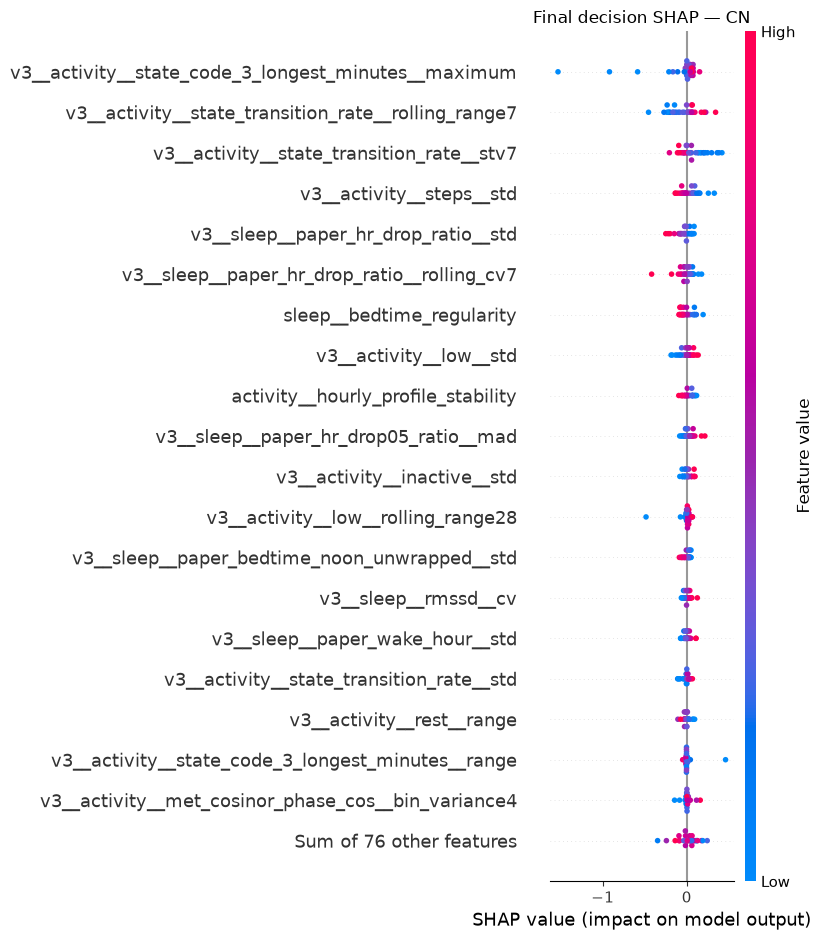

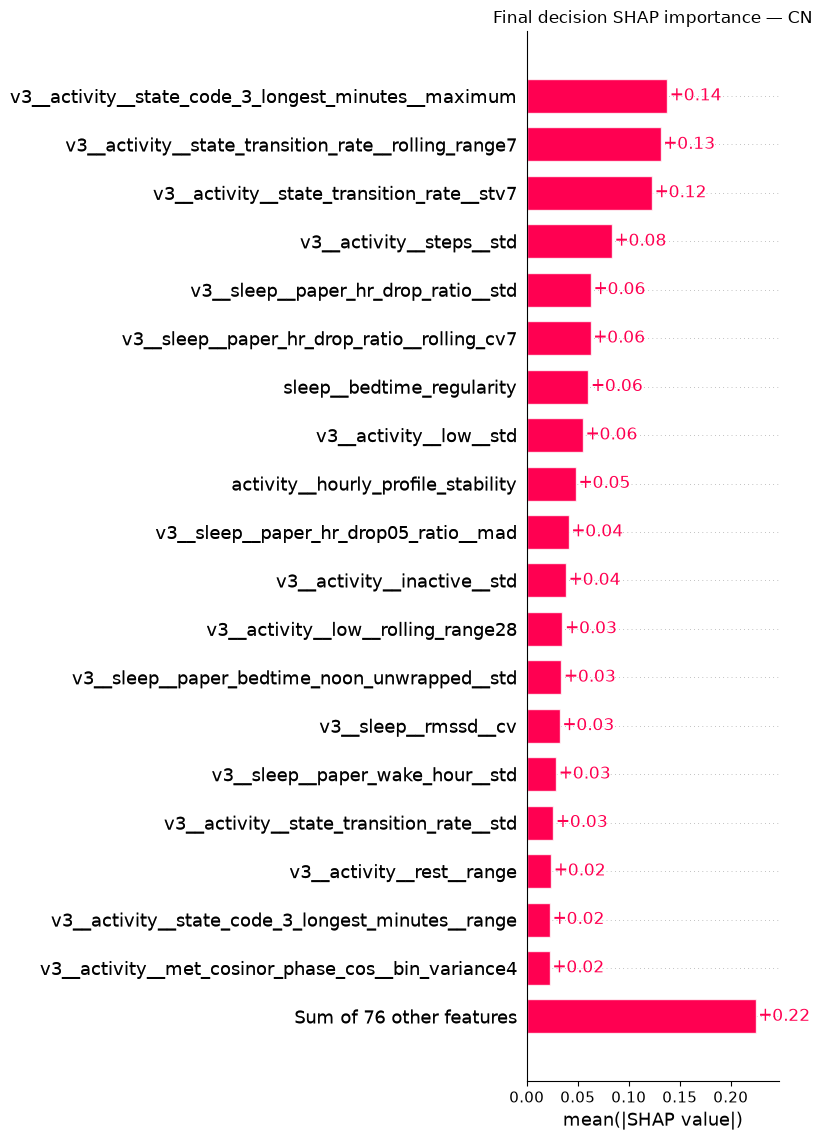

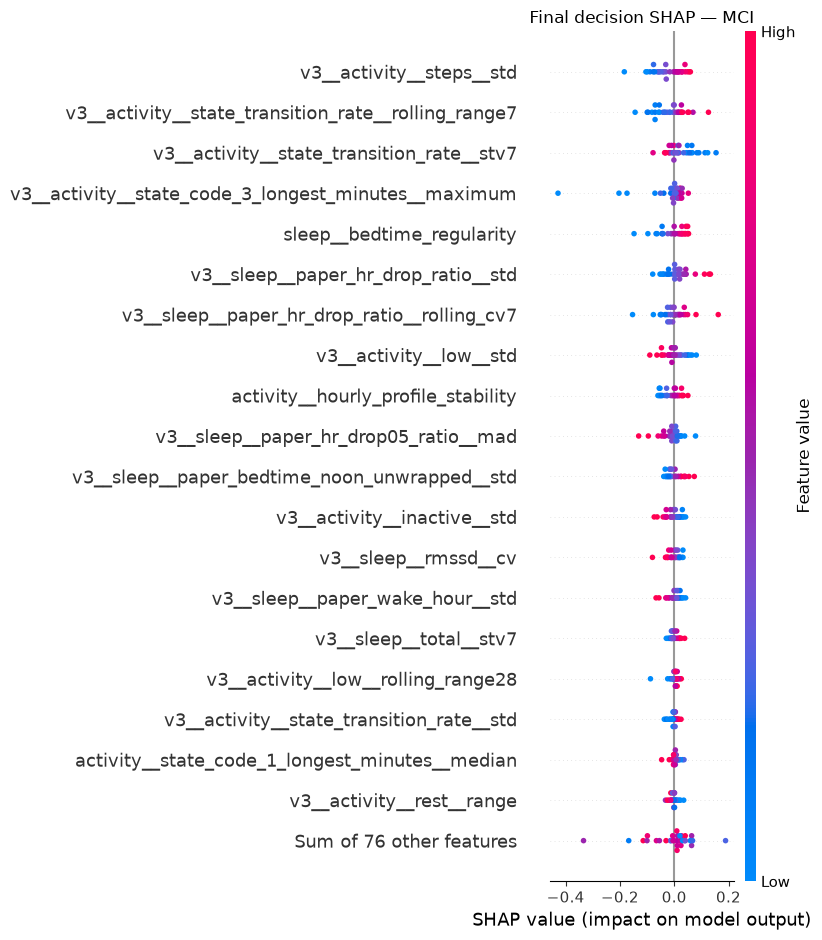

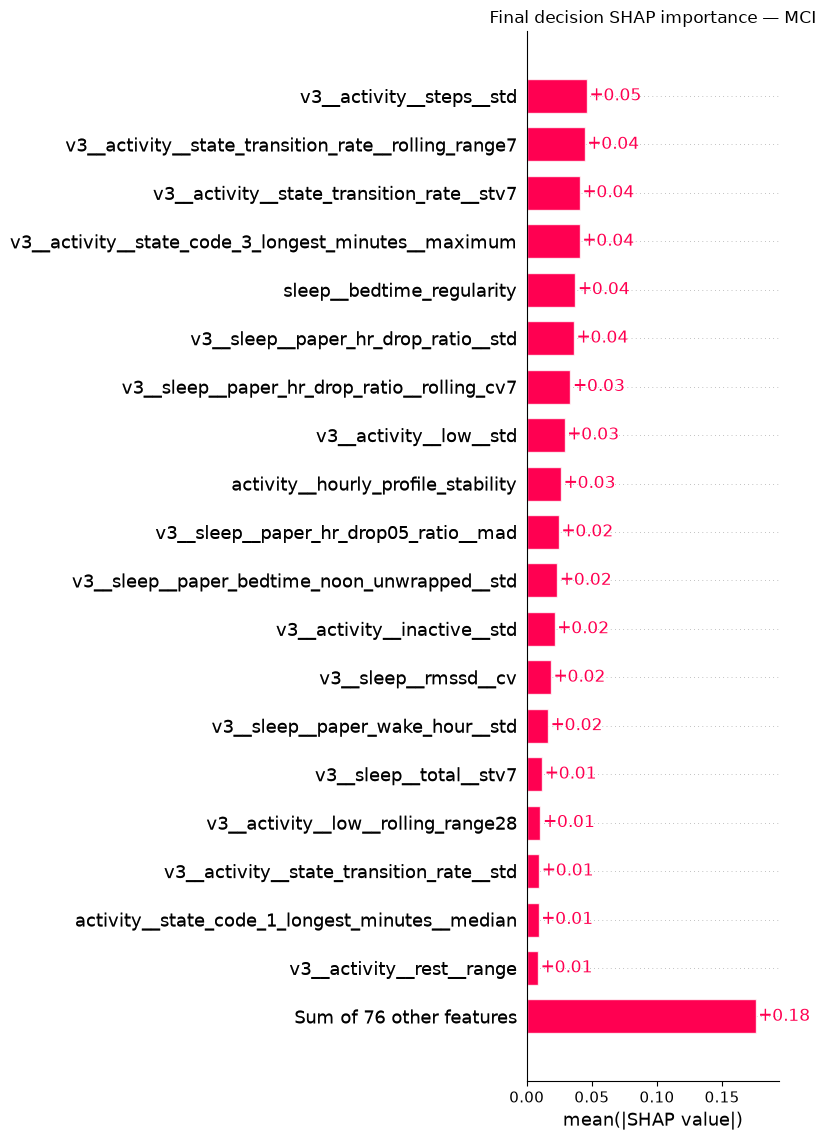

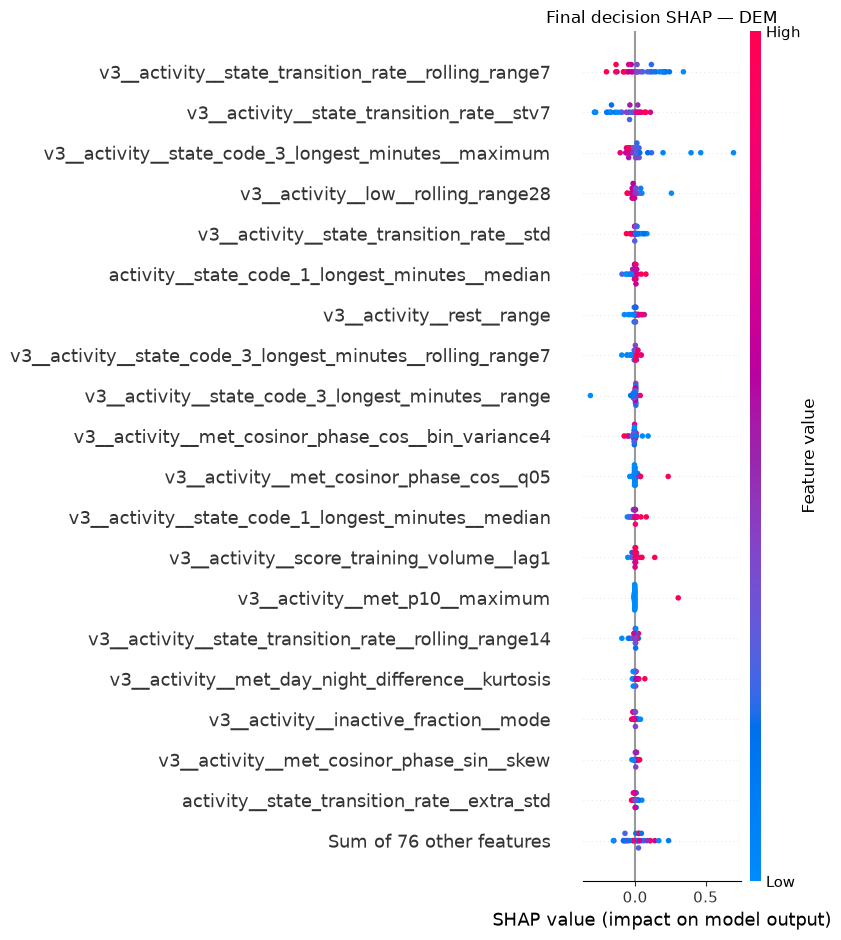

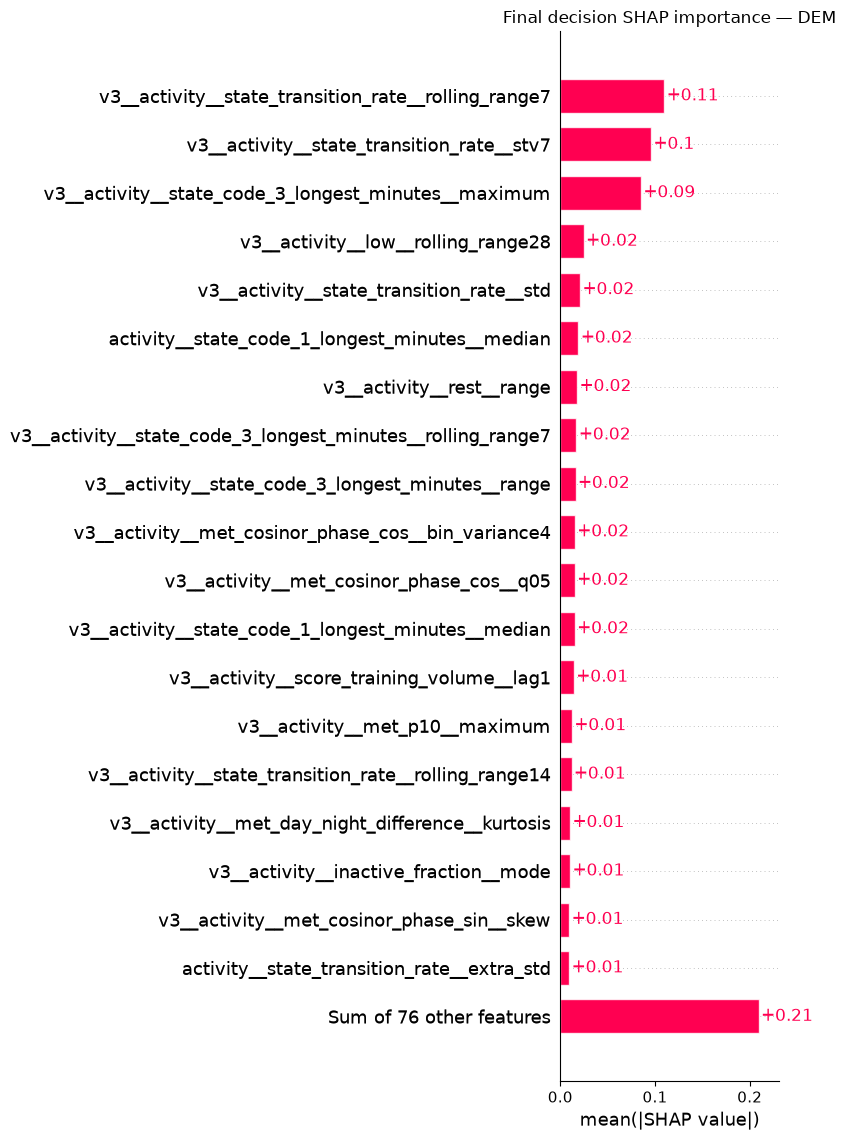

In [10]:

# -----------------------------
# Final SHAP global importance 저장
# -----------------------------
values = np.asarray(shap_final.values)

if values.ndim != 3 or values.shape[2] != 3:
    raise RuntimeError(
        f"예상한 SHAP shape (n_subjects, n_features, 3)가 아닙니다: {values.shape}"
    )

mean_abs_by_class = np.mean(np.abs(values), axis=0)  # features x 3

final_shap_global = pd.DataFrame({
    "feature": union_features,
    "feature_readable": [readable_feature_name(x) for x in union_features],
    "mean_abs_shap_CN": mean_abs_by_class[:, 0],
    "mean_abs_shap_MCI": mean_abs_by_class[:, 1],
    "mean_abs_shap_DEM": mean_abs_by_class[:, 2],
})
final_shap_global["mean_abs_shap_macro"] = (
    final_shap_global[
        ["mean_abs_shap_CN", "mean_abs_shap_MCI", "mean_abs_shap_DEM"]
    ].mean(axis=1)
)

meta_reset = training.representations["subject"].meta.reset_index().rename(columns={"index":"feature"})
final_shap_global = final_shap_global.merge(meta_reset, on="feature", how="left")
final_shap_global = final_shap_global.sort_values(
    "mean_abs_shap_macro", ascending=False
).reset_index(drop=True)

display(final_shap_global.head(30))
final_shap_global.to_csv(
    OUT_DIR / "final_decision_shap_global.csv",
    index=False
)

joblib.dump(
    shap_final,
    OUT_DIR / "final_decision_shap_explanation.joblib",
    compress=3
)

for k, class_name in enumerate(CLASS_NAMES):
    class_exp = shap_final[:, :, k]

    plt.figure()
    shap.plots.beeswarm(
        class_exp,
        max_display=20,
        show=False
    )
    plt.title(f"Final decision SHAP — {class_name}")
    plt.tight_layout()
    plt.savefig(
        OUT_DIR / f"final_shap_beeswarm_{class_name}.png",
        dpi=180,
        bbox_inches="tight"
    )
    plt.show()

    plt.figure()
    shap.plots.bar(
        class_exp,
        max_display=20,
        show=False
    )
    plt.title(f"Final decision SHAP importance — {class_name}")
    plt.tight_layout()
    plt.savefig(
        OUT_DIR / f"final_shap_bar_{class_name}.png",
        dpi=180,
        bbox_inches="tight"
    )
    plt.show()



# C. 계층형 branch별 SHAP

전체 3-class SHAP만 보면 hierarchy 내부의 임상적 의미가 섞일 수 있으므로, 실제 최종 recipe에서 사용된 각 branch도 따로 설명합니다.

### DEM branch

positive output:

\[
P(DEM \mid x)
\]

에 해당하며, 해당 hierarchy에서 실제 사용된 temperature와 bias까지 적용한 score를 설명합니다.

### CN/MCI branch

DEM 피험자를 제외하고 positive output:

\[
P(MCI \mid CN\ or\ MCI, x)
\]

를 설명합니다.

따라서:

- DEM branch SHAP > 0 → DEM 방향
- CN/MCI branch SHAP > 0 → MCI 방향
- CN/MCI branch SHAP < 0 → CN 방향

입니다.


Hierarchy 1 / DEM_vs_nonDEM / rbf_ridge: 20 features, 33 validation subjects


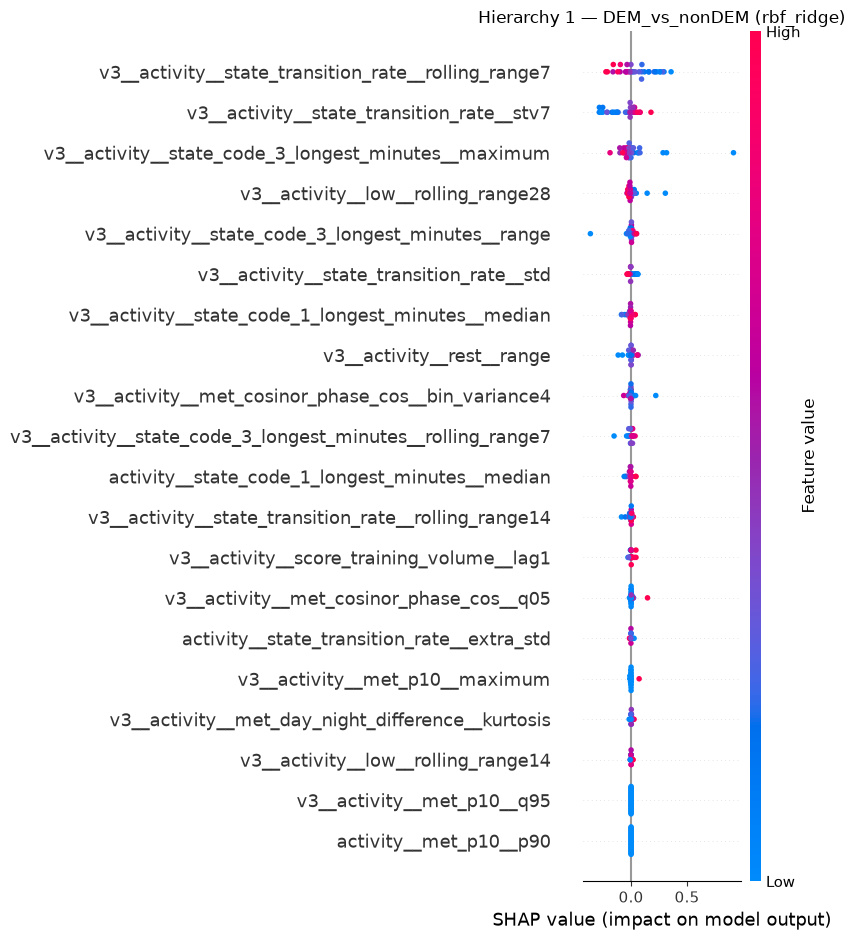

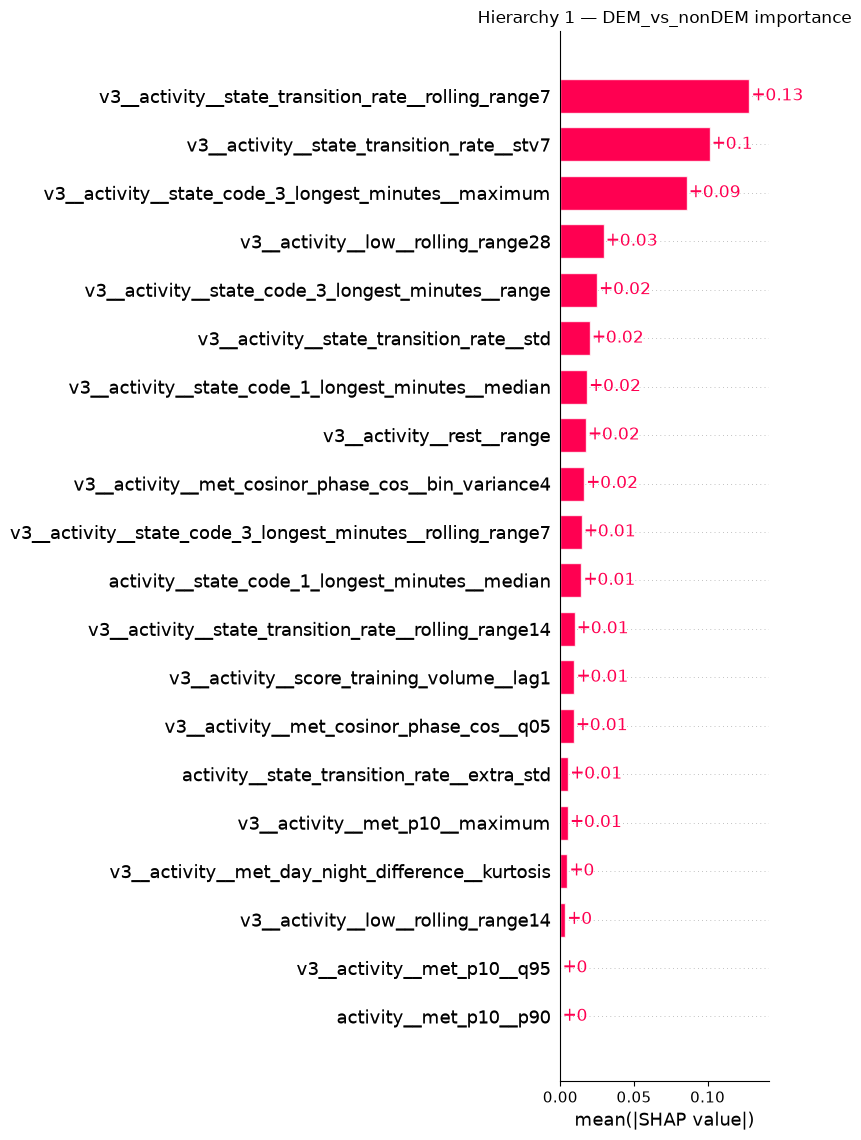

Hierarchy 1 / MCI_vs_CN / lda: 15 features, 30 validation subjects


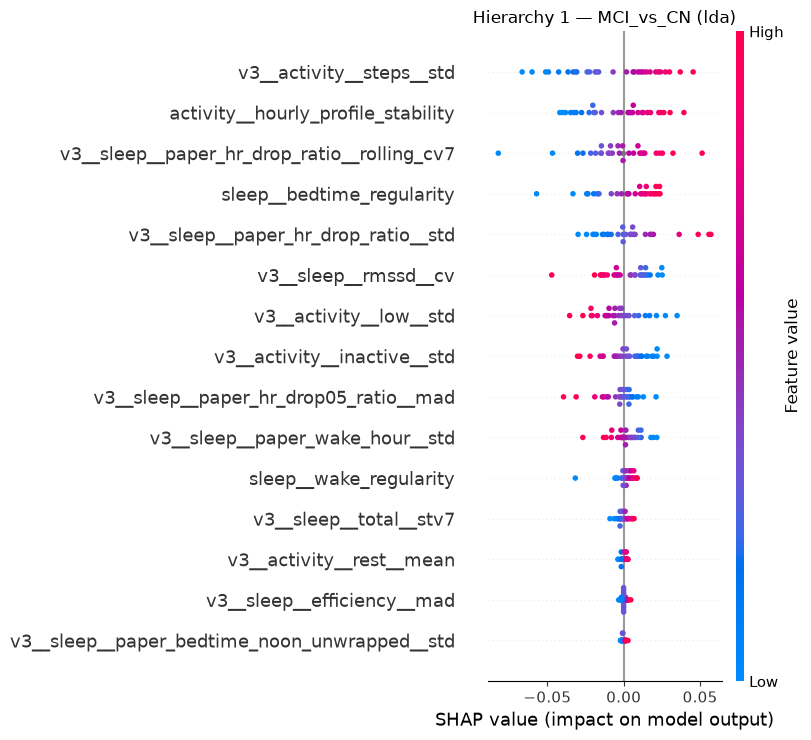

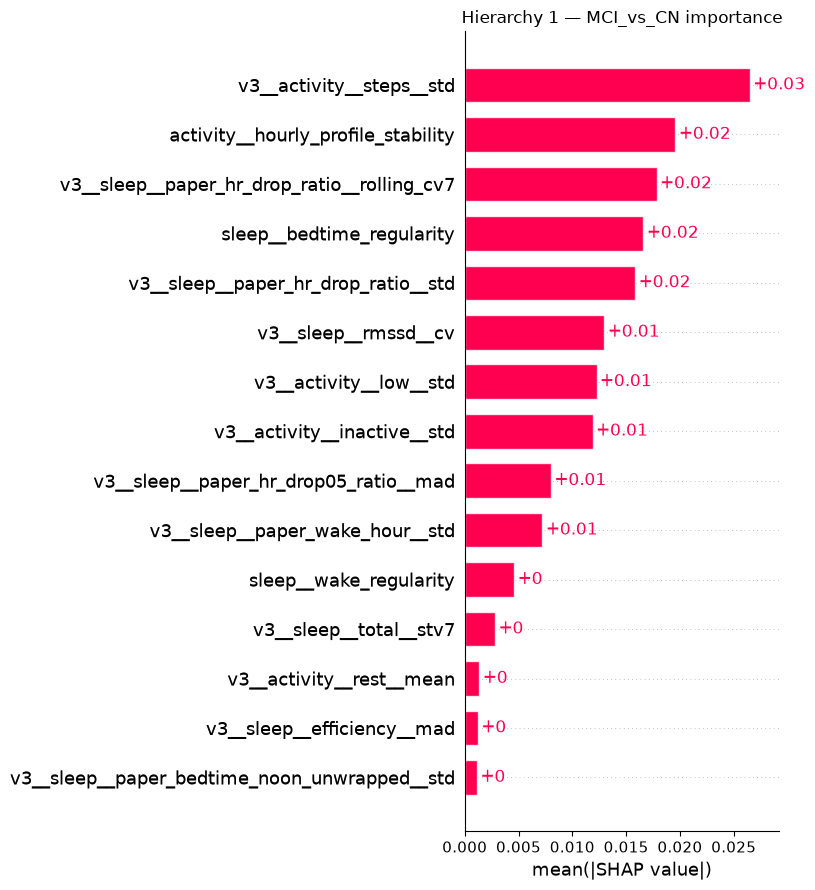

Hierarchy 2 / DEM_vs_nonDEM / rbf_ridge: 80 features, 33 validation subjects


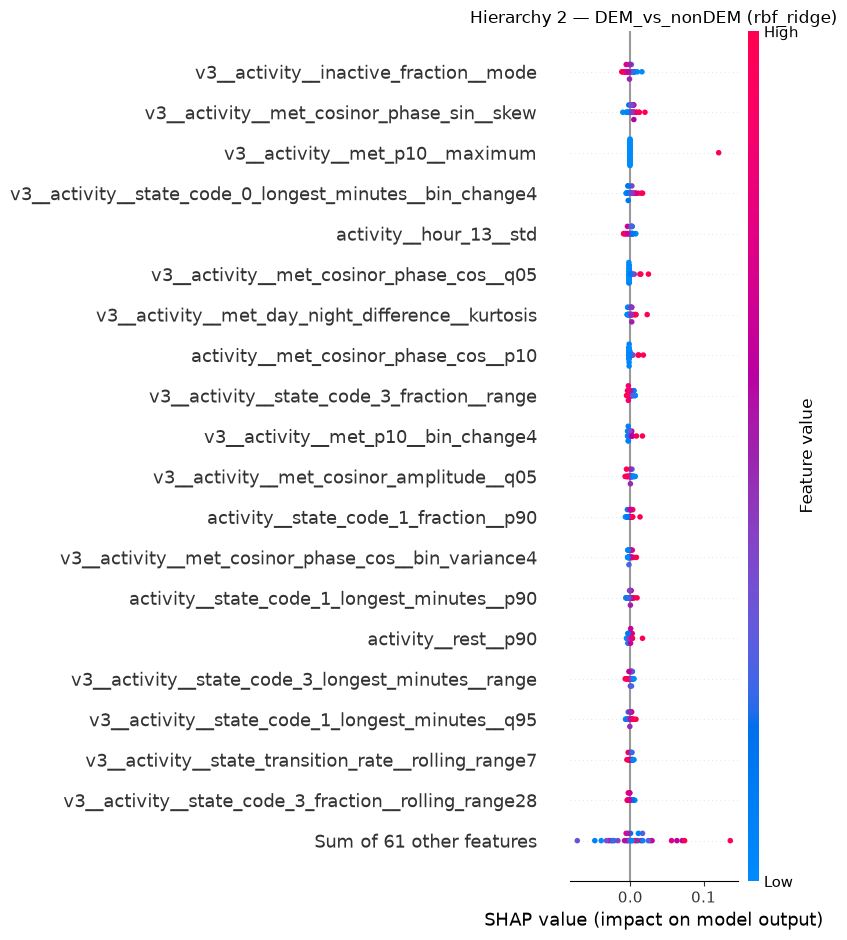

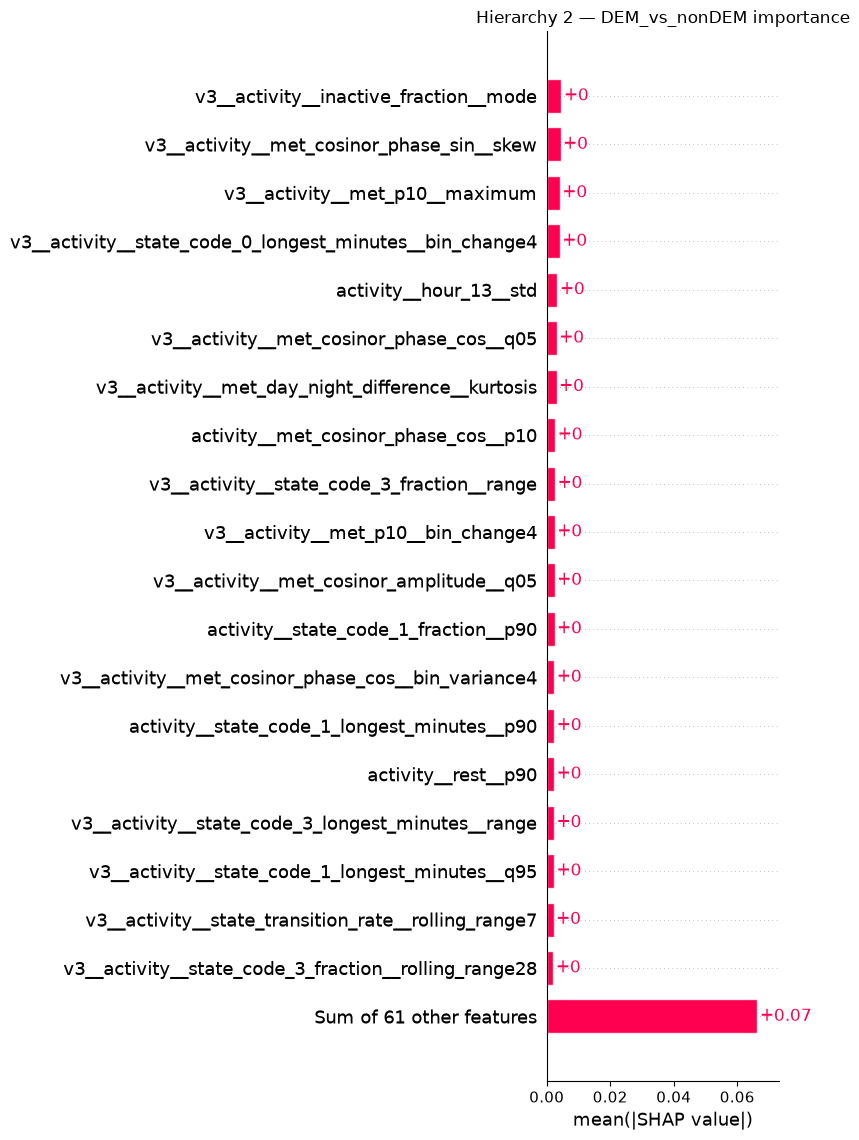

Hierarchy 2 / MCI_vs_CN / logreg: 15 features, 30 validation subjects


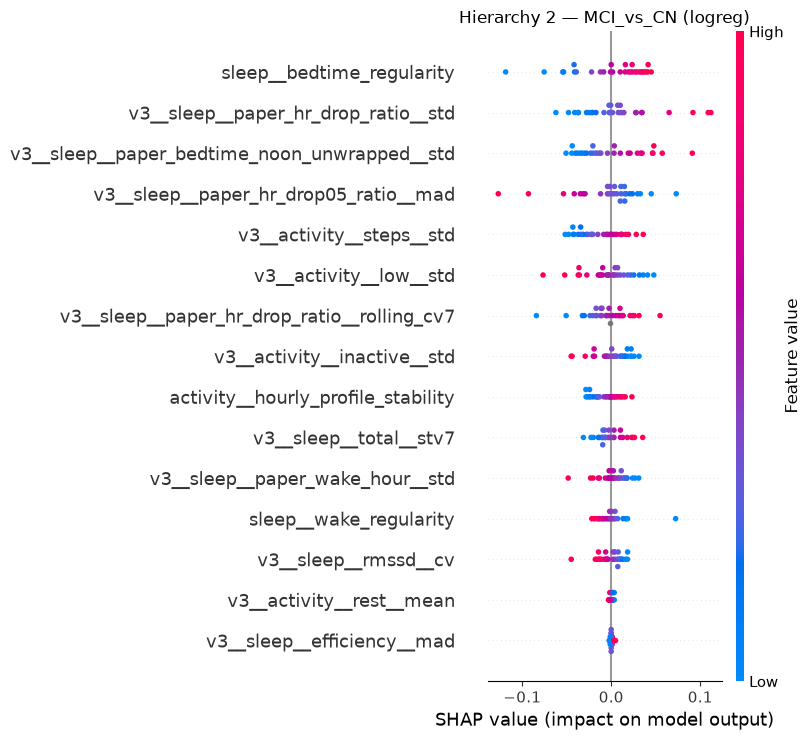

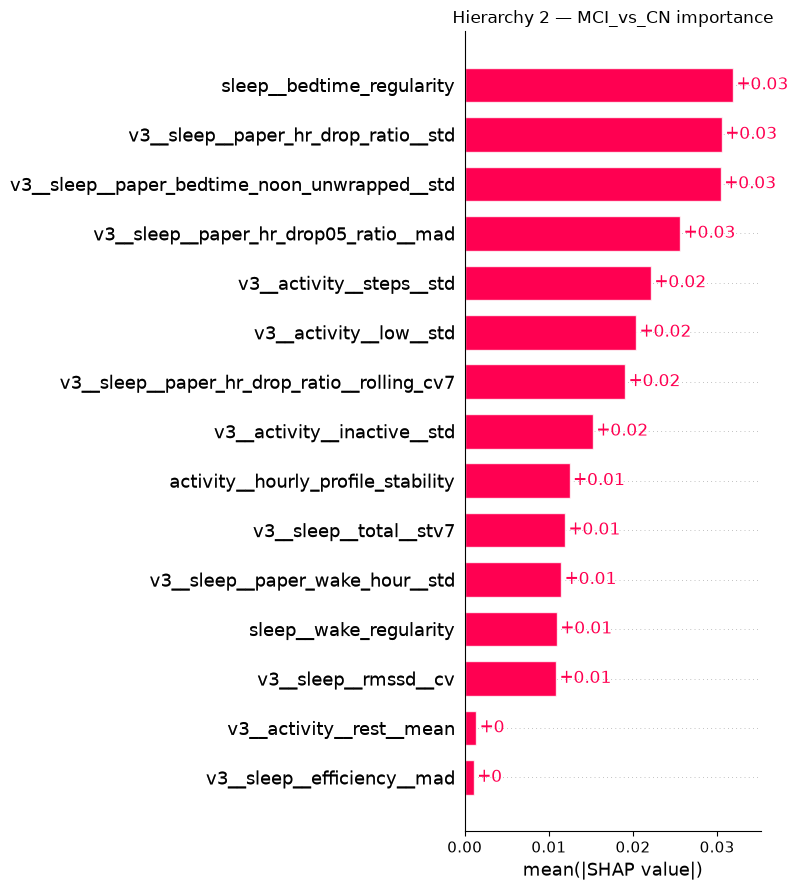

In [11]:

def calibrated_branch_positive_score(member, role, X_frame):
    if role == "dem":
        cid = member["dem_id"]
        raw = component_scores_from_frame(cid, X_frame)[:, 1]
        temp = member.get("dem_temperature", 1.0)
        bias = member.get("dem_bias", 0.0)
    elif role == "cn_mci":
        cid = member["cn_mci_id"]
        raw = component_scores_from_frame(cid, X_frame)[:, 1]
        temp = member.get("cn_mci_temperature", 1.0)
        bias = member.get("cn_mci_bias", 0.0)
    else:
        raise ValueError(role)

    raw = np.clip(raw, 1e-9, 1 - 1e-9)
    return expit(logit(raw) / temp + bias)

def run_one_branch_shap(hierarchy_index, role):
    member = champion.recipe["members"][hierarchy_index]

    if role == "dem":
        cid = member["dem_id"]
        role_name = "DEM_vs_nonDEM"
        train_subjects = list(training.subjects)
        val_subjects = list(selection.subjects)
    elif role == "cn_mci":
        cid = member["cn_mci_id"]
        role_name = "MCI_vs_CN"
        train_subjects = training.labels[
            training.labels.ne(2)
        ].index.tolist()
        val_subjects = selection.labels[
            selection.labels.ne(2)
        ].index.tolist()
    else:
        raise ValueError(role)

    fitted = champion.models[cid]
    features = list(fitted.processor.columns)

    X_bg = X_train_all.reindex(train_subjects)[features]
    X_ev = X_val_all.reindex(val_subjects)[features]

    if len(X_bg) > SHAP_BACKGROUND_MAX:
        X_bg = X_bg.sample(
            SHAP_BACKGROUND_MAX,
            random_state=SEED + hierarchy_index
        )

    if BRANCH_SHAP_MAX_ROWS is not None:
        X_ev = X_ev.iloc[:BRANCH_SHAP_MAX_ROWS]

    def score_fn(x):
        frame = _frame_from_shap_array(x, features)
        return calibrated_branch_positive_score(
            member, role, frame
        )

    masker = shap.maskers.Independent(
        X_bg,
        max_samples=min(SHAP_BACKGROUND_MAX, len(X_bg))
    )

    explainer = shap.Explainer(
        score_fn,
        masker,
        algorithm="permutation"
    )

    max_evals = 2 * len(features) + 1

    print(
        f"Hierarchy {hierarchy_index+1} / {role_name} / "
        f"{fitted.spec.family}: {len(features)} features, "
        f"{len(X_ev)} validation subjects"
    )

    sv = explainer(
        X_ev,
        max_evals=max_evals,
        batch_size=64,
    )

    vals = np.asarray(sv.values)
    if vals.ndim != 2:
        raise RuntimeError(
            f"Branch SHAP가 2차원이 아닙니다: {vals.shape}"
        )

    global_df = pd.DataFrame({
        "feature": features,
        "feature_readable": [readable_feature_name(x) for x in features],
        "mean_abs_shap": np.mean(np.abs(vals), axis=0),
        "mean_shap": np.mean(vals, axis=0),
        "hierarchy": hierarchy_index + 1,
        "role": role_name,
        "candidate_id": cid,
        "family": fitted.spec.family,
    })

    meta_reset = training.representations["subject"].meta.reset_index().rename(columns={"index":"feature"})
    global_df = global_df.merge(meta_reset, on="feature", how="left")
    global_df = global_df.sort_values(
        "mean_abs_shap", ascending=False
    ).reset_index(drop=True)

    stem = f"h{hierarchy_index+1}_{role_name}_{cid}"

    global_df.to_csv(
        OUT_DIR / f"{stem}_shap_global.csv",
        index=False
    )
    joblib.dump(
        sv,
        OUT_DIR / f"{stem}_shap_explanation.joblib",
        compress=3
    )

    plt.figure()
    shap.plots.beeswarm(
        sv,
        max_display=min(20, len(features)),
        show=False
    )
    plt.title(
        f"Hierarchy {hierarchy_index+1} — {role_name} ({fitted.spec.family})"
    )
    plt.tight_layout()
    plt.savefig(
        OUT_DIR / f"{stem}_beeswarm.png",
        dpi=180,
        bbox_inches="tight"
    )
    plt.show()

    plt.figure()
    shap.plots.bar(
        sv,
        max_display=min(20, len(features)),
        show=False
    )
    plt.title(
        f"Hierarchy {hierarchy_index+1} — {role_name} importance"
    )
    plt.tight_layout()
    plt.savefig(
        OUT_DIR / f"{stem}_bar.png",
        dpi=180,
        bbox_inches="tight"
    )
    plt.show()

    return {
        "hierarchy_index": hierarchy_index,
        "role": role,
        "role_name": role_name,
        "candidate_id": cid,
        "features": features,
        "shap": sv,
        "global": global_df,
    }

branch_results = []

for h_idx in range(len(champion.recipe["members"])):
    branch_results.append(
        run_one_branch_shap(h_idx, "dem")
    )
    branch_results.append(
        run_one_branch_shap(h_idx, "cn_mci")
    )



## 7. 두 hierarchy의 branch importance를 하나의 consensus 표로 요약

각 hierarchy의 SHAP 값 크기는 조금씩 다를 수 있으므로, 각 component 내부 `mean(|SHAP|)`을 합이 1이 되도록 정규화한 뒤 결합합니다.

- DEM consensus: 최종 ensemble의 DEM class weight 사용
- CN/MCI consensus: 최종 ensemble의 MCI class weight 사용

이 표는 **임상적 요약용 branch consensus**입니다.  
최종 3-class 모델의 정확한 전체 importance는 앞의 `final_decision_shap_global.csv` 및 permutation importance를 우선 사용합니다.


In [12]:

ensemble_weights = np.asarray(champion.recipe["weights"], dtype=float)

def branch_consensus(role):
    if role == "dem":
        selected = [r for r in branch_results if r["role"] == "dem"]
        weights = ensemble_weights[:, 2].astype(float)
        label = "DEM_vs_nonDEM"
    elif role == "cn_mci":
        selected = [r for r in branch_results if r["role"] == "cn_mci"]
        weights = ensemble_weights[:, 1].astype(float)
        label = "MCI_vs_CN"
    else:
        raise ValueError(role)

    weights = weights / weights.sum()

    feature_union = []
    for r in selected:
        feature_union.extend(r["global"]["feature"].tolist())
    feature_union = list(dict.fromkeys(feature_union))

    acc = pd.Series(0.0, index=feature_union)

    for w, r in zip(weights, selected):
        s = r["global"].set_index("feature")["mean_abs_shap"].reindex(feature_union).fillna(0.0)
        if s.sum() > 0:
            s = s / s.sum()
        acc = acc + w * s

    out = pd.DataFrame({
        "feature": acc.index,
        "feature_readable": [readable_feature_name(x) for x in acc.index],
        "consensus_importance": acc.values,
    })

    meta_reset = training.representations["subject"].meta.reset_index().rename(columns={"index":"feature"})
    out = out.merge(meta_reset, on="feature", how="left")
    out = out.sort_values(
        "consensus_importance", ascending=False
    ).reset_index(drop=True)

    out.to_csv(
        OUT_DIR / f"branch_consensus_{label}.csv",
        index=False
    )
    return out

dem_consensus = branch_consensus("dem")
cnmci_consensus = branch_consensus("cn_mci")

display(Markdown("### DEM vs non-DEM consensus"))
display(dem_consensus.head(30))

display(Markdown("### MCI vs CN consensus"))
display(cnmci_consensus.head(30))


### DEM vs non-DEM consensus

,feature,feature_readable,consensus_importance,modality,family,description,kind
0,v3__activity__state_transition_rate__rolling_r...,v3__activity__state_transition_rate__rolling_r...,0.095156,activity,physiology,activity__state_transition_rate: within-person...,temporal_v3
1,v3__activity__state_transition_rate__stv7,v3__activity__state_transition_rate__stv7,0.074124,activity,physiology,activity__state_transition_rate: within-person...,temporal_v3
2,v3__activity__state_code_3_longest_minutes__ma...,v3__activity__state_3_low_intensity_activity_l...,0.065608,activity,physiology,activity__state_code_3_longest_minutes: within...,temporal_v3
3,v3__activity__low__rolling_range28,v3__activity__low__rolling_range28,0.028763,activity,physiology,activity__low: within-person rolling_range28; ...,temporal_v3
4,v3__activity__state_code_3_longest_minutes__range,v3__activity__state_3_low_intensity_activity_l...,0.028712,activity,physiology,activity__state_code_3_longest_minutes: within...,temporal_v3
5,v3__activity__met_p10__maximum,v3__activity__met_p10__maximum,0.025805,activity,physiology,activity__met_p10: within-person maximum; cale...,temporal_v3
6,v3__activity__inactive_fraction__mode,v3__activity__inactive_fraction__mode,0.025240,activity,physiology,activity__inactive_fraction: within-person mod...,temporal_v3
7,v3__activity__met_cosinor_phase_sin__skew,v3__activity__met_cosinor_phase_sin__skew,0.023837,activity,physiology,activity__met_cosinor_phase_sin: within-person...,temporal_v3
8,v3__activity__met_cosinor_phase_cos__bin_varia...,v3__activity__met_cosinor_phase_cos__bin_varia...,0.023504,activity,physiology,activity__met_cosinor_phase_cos: within-person...,temporal_v3
9,v3__activity__met_cosinor_phase_cos__q05,v3__activity__met_cosinor_phase_cos__q05,0.023035,activity,physiology,activity__met_cosinor_phase_cos: within-person...,temporal_v3


### MCI vs CN consensus

,feature,feature_readable,consensus_importance,modality,family,description,kind
0,sleep__bedtime_regularity,sleep__bedtime_regularity,0.118359,sleep,physiology,시각 원형 resultant length: 1에 가까울수록 규칙적,v2
1,v3__sleep__paper_hr_drop_ratio__std,v3__sleep__paper_hr_drop_ratio__std,0.113304,sleep,physiology,sleep__paper_hr_drop_ratio: within-person std;...,temporal_v3
2,v3__activity__steps__std,v3__activity__steps__std,0.110825,activity,physiology,activity__steps: within-person std; calendar w...,temporal_v3
3,v3__sleep__paper_hr_drop_ratio__rolling_cv7,v3__sleep__paper_hr_drop_ratio__rolling_cv7,0.085932,sleep,physiology,sleep__paper_hr_drop_ratio: within-person roll...,temporal_v3
4,v3__sleep__paper_hr_drop05_ratio__mad,v3__sleep__paper_hr_drop05_ratio__mad,0.084853,sleep,physiology,sleep__paper_hr_drop05_ratio: within-person ma...,temporal_v3
5,v3__sleep__paper_bedtime_noon_unwrapped__std,v3__sleep__paper_bedtime_noon_unwrapped__std,0.084822,sleep,physiology,sleep__paper_bedtime_noon_unwrapped: within-pe...,temporal_v3
6,v3__activity__low__std,v3__activity__low__std,0.078766,activity,physiology,activity__low: within-person std; calendar win...,temporal_v3
7,activity__hourly_profile_stability,activity__hourly_profile_stability,0.071397,activity,physiology,분산 가중 시간대 반복성; 표준 actigraphy IS와 동일한 지표라고 주장하지 않음,v2
8,v3__activity__inactive__std,v3__activity__inactive__std,0.064155,activity,physiology,activity__inactive: within-person std; calenda...,temporal_v3
9,v3__sleep__rmssd__cv,v3__sleep__rmssd__cv,0.054384,sleep,physiology,sleep__rmssd: within-person cv; calendar windo...,temporal_v3



# D. 대표 피험자 local SHAP waterfall

Validation에서 각 실제 class별로 **정답 예측된 첫 번째 피험자**를 하나씩 골라, 해당 class의 최종 decision score SHAP을 waterfall로 저장합니다.

이 그림은 개별 사례 설명용이며, global importance의 근거로 사용하지 않습니다.


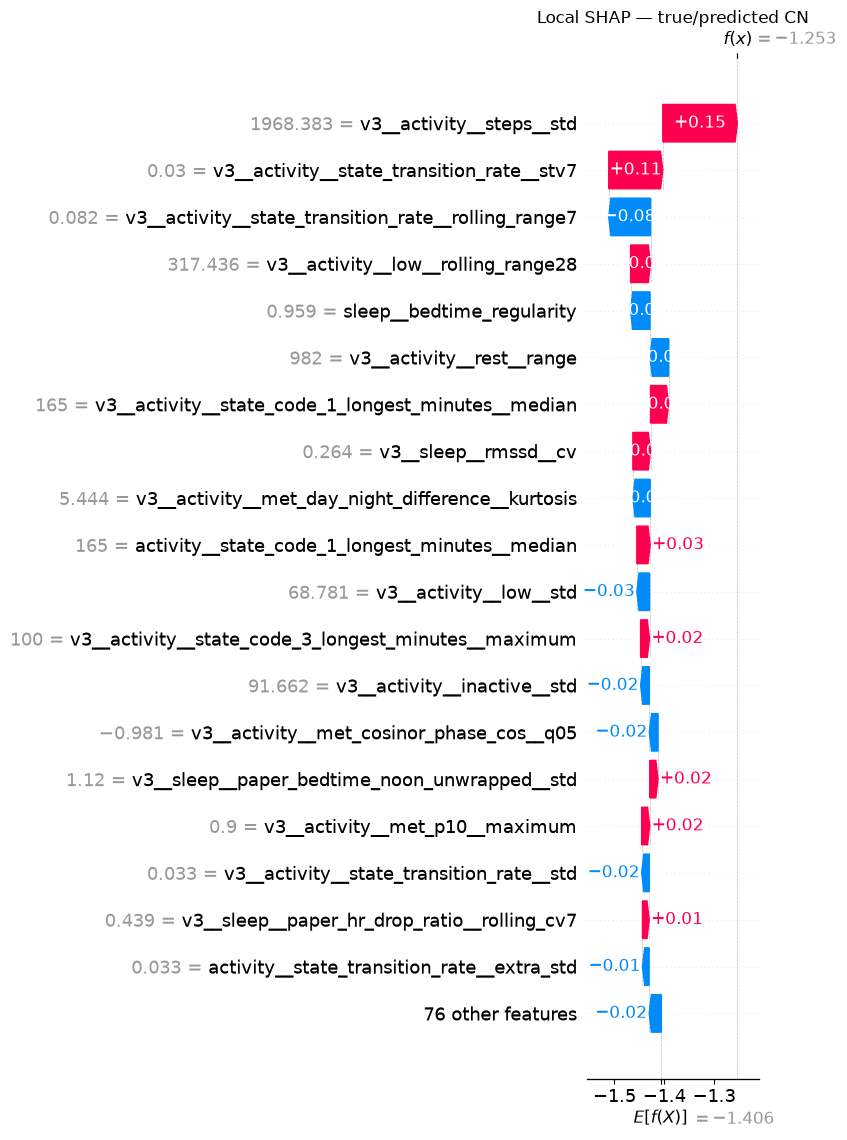

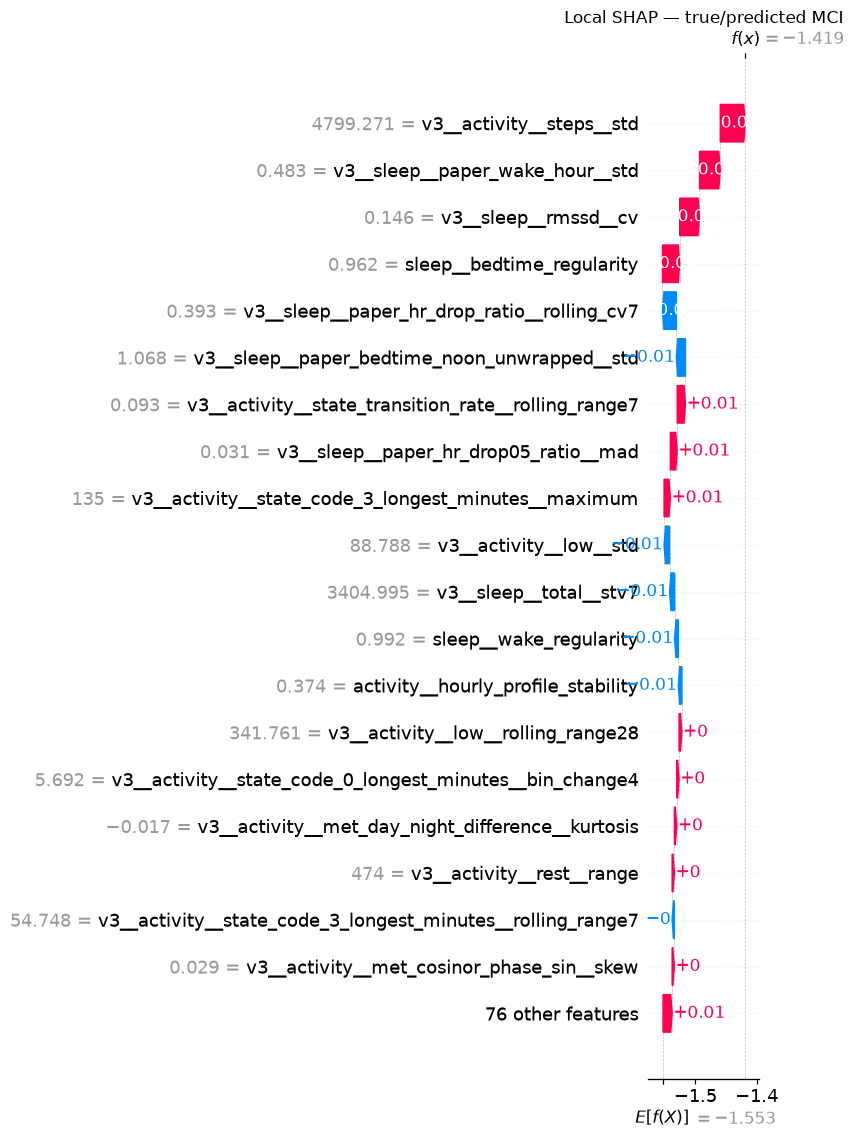

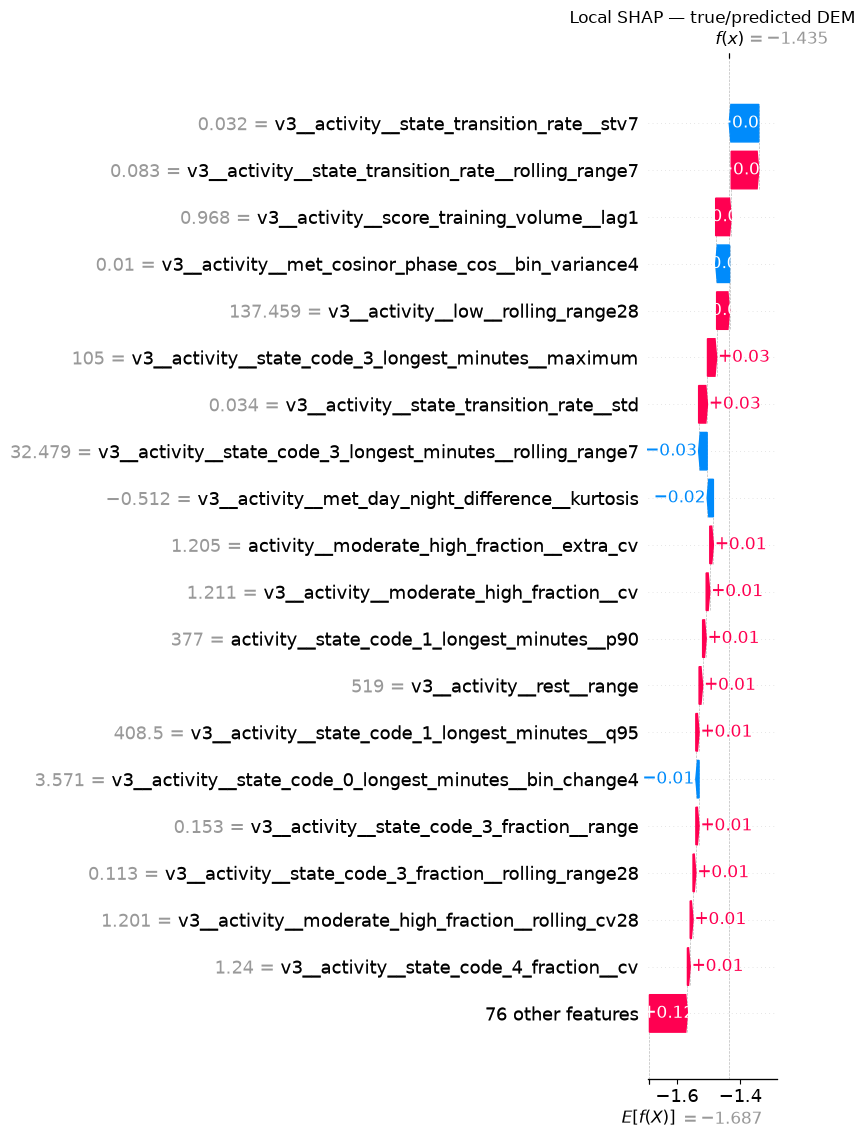

,class,subject_hash,plot
0,CN,0387edf34eb68a222659220d7a2b9c76cab1e7a7061617...,/Users/pig30nidae/my_lab/results_v3/run_full/s...
1,MCI,5fee99d6db4fed746cce809a4e7edb9ee02d578f841b9f...,/Users/pig30nidae/my_lab/results_v3/run_full/s...
2,DEM,357291594c74840f8cd441373ab1ee382e92d544658290...,/Users/pig30nidae/my_lab/results_v3/run_full/s...


In [13]:

# shap_final의 row index는 X_explain_final.index 순서와 같습니다.
explained_subjects = list(X_explain_final.index)
subject_to_row = {s: i for i, s in enumerate(explained_subjects)}

local_rows = []

for k, class_name in enumerate(CLASS_NAMES):
    candidates = [
        s for s, yt, hp in zip(
            selection.subjects,
            y_val,
            h_check
        )
        if yt == k and hp == k and s in subject_to_row
    ]

    if not candidates:
        print(f"{class_name}: 설명 가능한 correctly classified subject 없음")
        continue

    subject = candidates[0]
    row_i = subject_to_row[subject]

    local_exp = shap_final[row_i, :, k]

    plt.figure()
    shap.plots.waterfall(
        local_exp,
        max_display=20,
        show=False
    )
    plt.title(f"Local SHAP — true/predicted {class_name}")
    plt.tight_layout()
    path = OUT_DIR / f"local_waterfall_{class_name}.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()

    local_rows.append({
        "class": class_name,
        "subject_hash": subject,
        "plot": str(path),
    })

local_examples = pd.DataFrame(local_rows)
local_examples.to_csv(
    OUT_DIR / "local_examples.csv",
    index=False
)
display(local_examples)



# 8. 최종 결과 파일 확인

논문/보고서에서 우선 확인할 파일:

### 전체 champion

- `final_ensemble_permutation_importance.csv`
- `final_decision_shap_global.csv`
- `final_shap_beeswarm_CN.png`
- `final_shap_beeswarm_MCI.png`
- `final_shap_beeswarm_DEM.png`

### 임상적 branch 해석

- `branch_consensus_DEM_vs_nonDEM.csv`
- `branch_consensus_MCI_vs_CN.csv`
- 각 hierarchy의 `*_shap_global.csv`
- 각 hierarchy의 `*_beeswarm.png`

## 해석 순서 권장

1. **Permutation Importance**로 최종 3-class champion 전체에서 실제 성능에 영향이 큰 feature 확인
2. **Final class-specific SHAP**으로 CN/MCI/DEM 방향성 확인
3. **Branch SHAP**으로
   - DEM vs non-DEM
   - MCI vs CN
   의 임상적 의미를 분리
4. 그 뒤에만 선행 임상 문헌과 연결

특히 `mean(|SHAP|)`가 크다는 사실만으로 “위험 요인”이라고 표현하면 안 됩니다.  
위험 방향을 말하려면 beeswarm / dependence / 개별 SHAP 부호까지 확인해야 합니다.


In [14]:

print("SHAP 분석 출력 폴더:")
print(OUT_DIR.resolve())

files = sorted(
    p.name for p in OUT_DIR.iterdir()
    if p.is_file()
)

display(pd.DataFrame({"generated_file": files}))

print("\nTop 15 — final permutation importance")
display(
    perm_importance[
        [
            "feature_readable",
            "delta_macro_auc_mean",
            "delta_macro_auc_sd",
            "delta_auc_CN_mean",
            "delta_auc_MCI_mean",
            "delta_auc_DEM_mean",
        ]
    ].head(15)
)

print("\nTop 15 — final class-specific SHAP")
display(
    final_shap_global[
        [
            "feature_readable",
            "mean_abs_shap_macro",
            "mean_abs_shap_CN",
            "mean_abs_shap_MCI",
            "mean_abs_shap_DEM",
        ]
    ].head(15)
)


SHAP 분석 출력 폴더:
/Users/pig30nidae/my_lab/results_v3/run_full/shap_analysis


,generated_file
0,branch_consensus_DEM_vs_nonDEM.csv
1,branch_consensus_MCI_vs_CN.csv
2,champion_feature_dictionary.csv
3,component_inventory.csv
4,final_decision_shap_explanation.joblib
5,final_decision_shap_global.csv
6,final_ensemble_permutation_importance.csv
7,final_ensemble_permutation_importance_top25.png
8,final_shap_bar_CN.png
9,final_shap_bar_DEM.png



Top 15 — final permutation importance


,feature_readable,delta_macro_auc_mean,delta_macro_auc_sd,delta_auc_CN_mean,delta_auc_MCI_mean,delta_auc_DEM_mean
0,v3__activity__state_3_low_intensity_activity_l...,0.099068,0.037801,0.166593,0.033276,0.097333
1,v3__activity__state_transition_rate__stv7,0.092569,0.039040,0.067143,0.161897,0.048667
2,v3__activity__state_transition_rate__rolling_r...,0.080811,0.044367,0.102637,0.072241,0.067556
3,v3__activity__state_3_low_intensity_activity_l...,0.064128,0.023666,-0.003297,0.178793,0.016889
4,v3__sleep__paper_hr_drop_ratio__std,0.059053,0.025691,0.058022,0.119138,0.000000
5,sleep__bedtime_regularity,0.056228,0.033001,0.049890,0.118793,0.000000
6,v3__activity__low__std,0.054871,0.023378,0.053407,0.111207,0.000000
7,v3__activity__state_3_low_intensity_activity_l...,0.046573,0.025846,-0.006044,0.136207,0.009556
8,v3__activity__steps__std,0.045813,0.034702,0.056264,0.073621,0.007556
9,v3__activity__rest__range,0.044295,0.027466,-0.004505,0.126724,0.010667



Top 15 — final class-specific SHAP


,feature_readable,mean_abs_shap_macro,mean_abs_shap_CN,mean_abs_shap_MCI,mean_abs_shap_DEM
0,v3__activity__state_transition_rate__rolling_r...,0.095160,0.131169,0.044437,0.109874
1,v3__activity__state_3_low_intensity_activity_l...,0.087804,0.137537,0.040618,0.085258
2,v3__activity__state_transition_rate__stv7,0.086437,0.122764,0.040691,0.095855
3,v3__activity__steps__std,0.044709,0.083421,0.046135,0.004569
4,v3__sleep__paper_hr_drop_ratio__std,0.033463,0.062883,0.036148,0.001359
5,sleep__bedtime_regularity,0.032989,0.060289,0.037253,0.001425
6,v3__sleep__paper_hr_drop_ratio__rolling_cv7,0.032586,0.062562,0.033468,0.001728
7,v3__activity__low__std,0.028410,0.055019,0.029037,0.001174
8,activity__hourly_profile_stability,0.025862,0.048146,0.026272,0.003167
9,v3__activity__low__rolling_range28,0.023357,0.034963,0.010429,0.024679
